# Final Project: End-to-End News Category Classification using DistilBERT

**Course:** DX703 - Advanced Machine Learning and AI  
**Team Members:** Jenny James, Sergey Nelyapanko, Lexi Fortuna  
**Date:** April, 26 2026  

**Objective:**  
This notebook implements a complete machine learning pipeline for classifying HuffPost news articles into 31 categories using both baseline and advanced deep learning models, culminating in a fine-tuned DistilBERT model.

## A.1: Setup and Context

### Problem Statement

This project addresses a multi-class text classification problem: automatically assigning news articles to one of 31 categories using headline and short description text.

### Dataset

We used the HuffPost News Category Dataset (~200K samples).

Key preprocessing steps:
- Merged overlapping categories (41 → 31)
- Removed duplicates and missing headlines
- Addressed class imbalance (29x skew)

### Summary of Milestones

**Milestone 1:**
- Data cleaning and category merging
- Exploratory data analysis (class imbalance, missing data)

**Milestone 2:**
- Implemented multiple models:
  - Baseline (Embedding + AvgPooling)
  - LSTM / BiLSTM
  - Enhanced baseline
  - DistilBERT (transfer learning)

**Key Insight:**
From-scratch models plateaued (~56% accuracy), while DistilBERT significantly improved performance (~71% accuracy).

### Imports + Config(Code)

In [1]:
# Environment detection: Colab / Kaggle / Local
import sys, os

IN_COLAB  = "google.colab" in sys.modules
IN_KAGGLE = "KAGGLE_KERNEL_RUN_TYPE" in os.environ or os.path.exists("/kaggle")

if IN_COLAB:
    !pip install -q "transformers<5" tf-keras tensorflow "huggingface_hub<0.28"
elif IN_KAGGLE:
    !pip install -q "transformers<5" tf-keras "huggingface_hub<0.28"
else:
    # Local env assumed pre-configured via pyproject.toml / uv
    pass

print(f"Env: Colab={IN_COLAB}, Kaggle={IN_KAGGLE}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 1.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import os, time, json, gc, random
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from datasets import load_dataset
import requests
import json
from datasets import Dataset
import sys
import tensorflow as tf
from tensorflow import keras
import requests
import tf_keras

from sklearn.metrics import classification_report, accuracy_score, f1_score

from transformers import (
    AutoTokenizer,
    TFAutoModelForSequenceClassification,
    create_optimizer
)




# — Sergey: Metal GPU adds dispatch overhead on small models (Embedding+Dense),
#   making them ~10x slower. Set False for P2-P3, True for P4 (BERT).
USE_GPU = True

if USE_GPU:
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPU enabled: {len(gpus)} device(s)")
    else:
        print("No GPU found — CPU only")
else:
    tf.config.set_visible_devices([], 'GPU')
    print("GPU disabled (CPU mode)")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
tf.random.set_seed(SEED)

def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))

2026-04-22 21:19:21.040120: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776892761.259558      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776892761.330826      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776892761.880312      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776892761.880353      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776892761.880356      23 computation_placer.cc:177] computation placer alr

GPU enabled: 2 device(s)


### Data Loading (Code)

In [3]:
URL = "https://huggingface.co/datasets/khalidalt/HuffPost/resolve/main/News_Category_Dataset_v2.json"
huff_all = load_dataset("json", data_files=URL, split="train")

print(huff_all)
print(f"Columns: {huff_all.column_names}")
print(f"Total samples: {len(huff_all):,}")

df = huff_all.to_pandas()
df.head(3)

News_Category_Dataset_v2.json:   0%|          | 0.00/83.9M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Dataset({
    features: ['category', 'headline', 'authors', 'link', 'short_description', 'date'],
    num_rows: 200853
})
Columns: ['category', 'headline', 'authors', 'link', 'short_description', 'date']
Total samples: 200,853


,category,headline,authors,link,short_description,date
0,CRIME,There Were 2 Mass Shootings In Texas Last Week...,Melissa Jeltsen,https://www.huffingtonpost.com/entry/texas-ama...,She left her husband. He killed their children...,2018-05-26
1,ENTERTAINMENT,Will Smith Joins Diplo And Nicky Jam For The 2...,Andy McDonald,https://www.huffingtonpost.com/entry/will-smit...,Of course it has a song.,2018-05-26
2,ENTERTAINMENT,Hugh Grant Marries For The First Time At Age 57,Ron Dicker,https://www.huffingtonpost.com/entry/hugh-gran...,The actor and his longtime girlfriend Anna Ebe...,2018-05-26


In [4]:
## special loading for colab
URL = "https://huggingface.co/datasets/khalidalt/HuffPost/resolve/main/News_Category_Dataset_v2.json"

# download file
response = requests.get(URL)
data = [json.loads(line) for line in response.text.splitlines()]

# convert to Hugging Face dataset
huff_all = Dataset.from_list(data)

print(huff_all)
print(f"Columns: {huff_all.column_names}")
print(f"Total samples: {len(huff_all):,}")

df = huff_all.to_pandas()
df.head(3)

Dataset({
    features: ['category', 'headline', 'authors', 'link', 'short_description', 'date'],
    num_rows: 200853
})
Columns: ['category', 'headline', 'authors', 'link', 'short_description', 'date']
Total samples: 200,853


,category,headline,authors,link,short_description,date
0,CRIME,There Were 2 Mass Shootings In Texas Last Week...,Melissa Jeltsen,https://www.huffingtonpost.com/entry/texas-ama...,She left her husband. He killed their children...,2018-05-26
1,ENTERTAINMENT,Will Smith Joins Diplo And Nicky Jam For The 2...,Andy McDonald,https://www.huffingtonpost.com/entry/will-smit...,Of course it has a song.,2018-05-26
2,ENTERTAINMENT,Hugh Grant Marries For The First Time At Age 57,Ron Dicker,https://www.huffingtonpost.com/entry/hugh-gran...,The actor and his longtime girlfriend Anna Ebe...,2018-05-26


### Final Preprocessing Pipeline

Steps:
- Merge categories
- Remove duplicates
- Handle missing descriptions
- Combine headline + description

In [5]:
# Merge confusable categories identified in Milestone 1
LABEL_MAP = {
    "ARTS & CULTURE": "ARTS", "CULTURE & ARTS": "ARTS",
    "THE WORLDPOST": "WORLD NEWS", "WORLDPOST": "WORLD NEWS",
    "PARENTS": "PARENTING",
    "STYLE & BEAUTY": "STYLE",
    "TASTE": "FOOD & DRINK",
    "GREEN": "ENVIRONMENT",
    "COLLEGE": "EDUCATION",
    "HEALTHY LIVING": "HOME & LIVING",
}

print(f"Before merge: {df['category'].nunique()} categories, {len(df):,} rows")

df["category"] = df["category"].replace(LABEL_MAP)

# Combine headline + description
df["text"] = df.apply(
    lambda r: (r["headline"] + " [SEP] " + r["short_description"]).strip()
    if pd.notna(r["short_description"]) and r["short_description"].strip()
    else r["headline"],
    axis=1,
)

# Drop empty headlines
empty_mask = df["headline"].isna() | (df["headline"].str.strip() == "")
print(f"Empty headlines dropped: {empty_mask.sum()}")
df = df[~empty_mask].copy()

# Remove exact duplicates (headline + short_description)
before_dedup = len(df)
df = df.drop_duplicates(subset=["headline", "short_description"], keep="first")
print(f"Duplicates removed: {before_dedup - len(df)}")

print(f"After cleaning: {df['category'].nunique()} categories, {len(df):,} rows")

Before merge: 41 categories, 200,853 rows
Empty headlines dropped: 6
Duplicates removed: 484
After cleaning: 31 categories, 200,363 rows


### Class Distribution

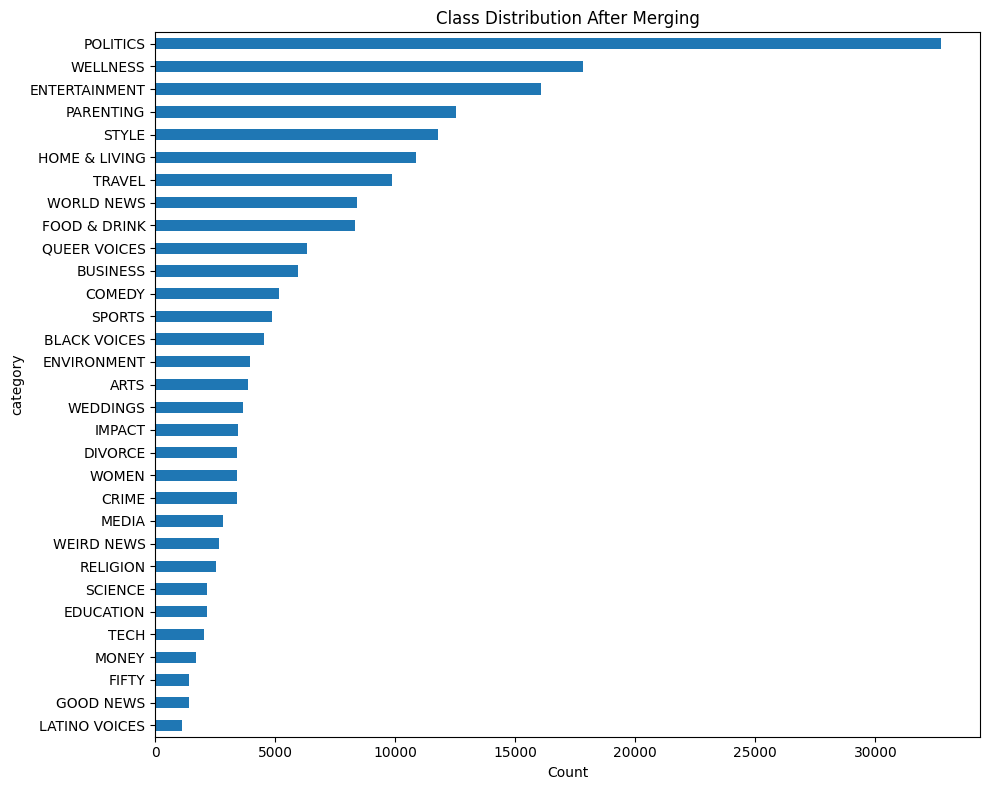

Categories: 31
Largest:  POLITICS (32,721)
Smallest: LATINO VOICES (1,129)
Median:   3,876
Imbalance ratio (max/min): 29.0x


In [6]:
counts = df["category"].value_counts()

fig, ax = plt.subplots(figsize=(10, 8))
counts.plot.barh(ax=ax)
ax.set_xlabel("Count")
ax.set_title("Class Distribution After Merging")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f"Categories: {len(counts)}")
print(f"Largest:  {counts.index[0]} ({counts.iloc[0]:,})")
print(f"Smallest: {counts.index[-1]} ({counts.iloc[-1]:,})")
print(f"Median:   {int(counts.median()):,}")
print(f"Imbalance ratio (max/min): {counts.iloc[0] / counts.iloc[-1]:.1f}x")

### Stratified Train / Val / Test Splits

In [7]:
texts = np.array(df["text"].tolist(), dtype=object)
labels = df["category"].tolist()

# Encode labels
class_names = sorted(set(labels))
label2id = {name: i for i, name in enumerate(class_names)}
y = np.array([label2id[c] for c in labels])
num_classes = len(class_names)

X_train, X_temp, y_train, y_temp = train_test_split(
    texts,
    y,
    test_size=0.20,
    stratify=y,
    random_state=SEED
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=SEED
)

print("Train size:", len(X_train))
print("Val size:", len(X_val))
print("Test size:", len(X_test))

print(f"Train: {len(X_train):,}  Val: {len(X_val):,}  Test: {len(X_test):,}")
print(f"Classes: {num_classes}")

# Compute class weights for imbalanced training
cw = compute_class_weight("balanced", classes=np.arange(num_classes), y=y_train)
class_weights = dict(enumerate(cw))
print(f"Class weight range: [{min(cw):.3f}, {max(cw):.3f}]")

Train size: 160290
Val size: 20036
Test size: 20037
Train: 160,290  Val: 20,036  Test: 20,037
Classes: 31
Class weight range: [0.198, 5.726]


### Text Length Distribution

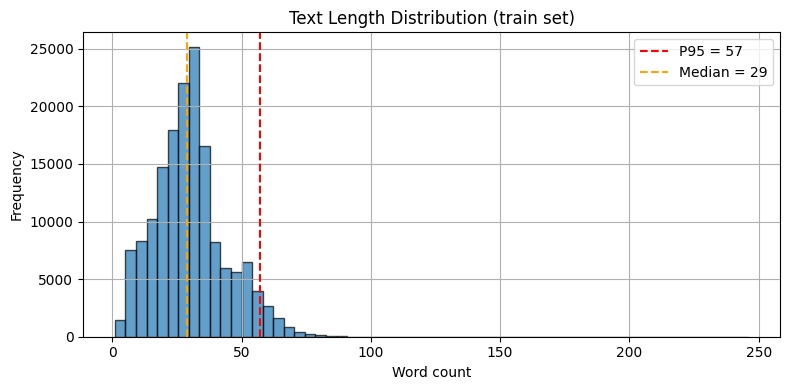

Mean:   30.2
Median: 29
P95:    57
P99:    68
Max:    246


In [8]:
word_counts = pd.Series([len(t.split()) for t in X_train])

fig, ax = plt.subplots(figsize=(8, 4))
word_counts.hist(bins=60, ax=ax, edgecolor="black", alpha=0.7)
ax.axvline(word_counts.quantile(0.95), color="red", ls="--", label=f"P95 = {word_counts.quantile(0.95):.0f}")
ax.axvline(word_counts.median(), color="orange", ls="--", label=f"Median = {word_counts.median():.0f}")
ax.set_xlabel("Word count")
ax.set_ylabel("Frequency")
ax.set_title("Text Length Distribution (train set)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Mean:   {word_counts.mean():.1f}")
print(f"Median: {word_counts.median():.0f}")
print(f"P95:    {word_counts.quantile(0.95):.0f}")
print(f"P99:    {word_counts.quantile(0.99):.0f}")
print(f"Max:    {word_counts.max()}")

## A.2: Model Selection and Retraining

### Final Model Selection

DistilBERT was selected as the final model because:
- Highest test accuracy (0.708)
- Highest macro F1 (0.621)
- Strong performance across all categories

From-scratch models failed to exceed ~56% accuracy, indicating limitations in representation learning.

#### Defining the needed functions to be used

In [9]:
from sklearn.metrics import classification_report, f1_score, confusion_matrix

RESULTS_FILE = "results/ms2_results.json"
results = {}

def save_results():
    os.makedirs(os.path.dirname(RESULTS_FILE), exist_ok=True)
    with open(RESULTS_FILE, "w") as f:
        json.dump(results, f, indent=2)
    print(f"Results saved ({len(results)} models)")

def load_results():
    global results
    try:
        with open(RESULTS_FILE) as f:
            results = json.load(f)
        if results:
            print(f"Restored {len(results)} results from {RESULTS_FILE}:")
            for name, r in results.items():
                print(f"  {name}: test_acc={r['test_acc']:.4f}, test_f1={r['test_f1']:.4f}")
    except FileNotFoundError:
        pass

def evaluate_model(model, name, X_te, y_te, hist, train_time, batch_size=512):
    preds = model.predict(X_te, batch_size=batch_size, verbose=0)

    # Handle Hugging Face TF models that return an object with `.logits`
    if hasattr(preds, "logits"):
        y_pred = np.argmax(preds.logits, axis=-1)
    else:
        y_pred = np.argmax(preds, axis=-1)

    test_acc = float(np.mean(y_pred == y_te))
    test_f1 = float(f1_score(y_te, y_pred, average="macro"))

    val_losses = hist.history["val_loss"]
    best_epoch = int(np.argmin(val_losses)) + 1
    val_acc = float(hist.history["val_accuracy"][best_epoch - 1])
    val_loss = float(val_losses[best_epoch - 1])

    results[name] = {
        "val_acc": val_acc,
        "val_loss": val_loss,
        "best_epoch": best_epoch,
        "test_acc": test_acc,
        "test_f1": test_f1,
        "params": model.count_params(),
        "train_time": train_time,
    }
    save_results()
    return y_pred

# Auto-restore on cell run
load_results()

#### Saving the confusion matrix confused pairs to a file as well for reporting later

In [10]:
def save_confused_pairs(confused,model_name, top_n=10):

    confused.sort(reverse=True)
    file_path="confused_pairs.csv"
    if top_n is not None:
        confused = confused[:top_n]

    new_df = pd.DataFrame(
        confused,
        columns=["Count", "True Label", "Predicted Label"]
    )
    new_df["Model"] = model_name
    new_df = new_df[["Model", "Count", "True Label", "Predicted Label"]]

    file_exists = os.path.exists(file_path)

    new_df.to_csv(
        file_path,
        mode="a",
        header=not file_exists,
        index=False
    )

    return new_df

### Learning Curves & Evaluation functions

In [11]:
def plot_learning_curves(hist, title):
    val_losses = hist.history["val_loss"]
    min_val_loss = min(val_losses)
    best_epoch = val_losses.index(min_val_loss)
    val_acc_best = hist.history["val_accuracy"][best_epoch]

    epochs = range(1, len(val_losses) + 1)
    fig, axs = plt.subplots(2, 1, figsize=(8, 7), sharex=True)

    axs[0].plot(epochs, hist.history["loss"], label="train")
    axs[0].plot(epochs, val_losses, label="val")
    axs[0].scatter(best_epoch + 1, min_val_loss, color="red", marker="x", s=60, label="best")
    axs[0].set_title(f"{title} — Loss")
    axs[0].set_ylabel("Loss")
    axs[0].legend()
    axs[0].grid(True)

    axs[1].plot(epochs, hist.history["accuracy"], label="train")
    axs[1].plot(epochs, hist.history["val_accuracy"], label="val")
    axs[1].scatter(best_epoch + 1, val_acc_best, color="red", marker="x", s=60, label="best")
    axs[1].set_title(f"{title} — Accuracy")
    axs[1].set_xlabel("Epoch")
    axs[1].set_ylabel("Accuracy")
    axs[1].legend()
    axs[1].grid(True)

    plt.tight_layout()
    plt.show()

    print(f"Best epoch: {best_epoch + 1}")
    print(f"Val loss:   {min_val_loss:.4f}")
    print(f"Val acc:    {val_acc_best:.4f}")
    return best_epoch + 1, val_acc_best

### DistilBERT Setup for HuffPost
Strategy:
- DistilBERT pretrained checkpoint
- Train on the full training set (`SUBSET_FRAC = 1.00`) for the final submission
- Freeze most of backbone
- Unfreeze only top 2 transformer blocks
- Small LR for stability

### Hyperparameter Definitions

In [12]:
## Configure
checkpoint = "distilbert-base-uncased"
MAX_LEN = 64
BATCH = 128
EPOCHS = 16
LR = 2e-5           # small LR for partial fine-tuning
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.1
SUBSET_FRAC = 1.00  # final submission: train on full training set (per rubric Part A)

es = tf_keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

t0 = time.time()

#### Training set selection
Set `SUBSET_FRAC = 1.00` above for the final full-data run. A smaller value (e.g. `0.50`) can be used for faster iteration.

In [13]:
# Use full training set when SUBSET_FRAC == 1.0, otherwise sample a stratified-free random subset
n_train = len(X_train)

if SUBSET_FRAC >= 1.0:
    X_train_sub = X_train
    y_train_sub = y_train
    print(f"Using full training set: {n_train:,} samples")
else:
    subset_size = int(n_train * SUBSET_FRAC)
    rng = np.random.default_rng(SEED)
    subset_idx = rng.choice(n_train, size=subset_size, replace=False)
    X_train_sub = X_train[subset_idx]
    y_train_sub = y_train[subset_idx]
    print(f"Using subset: {subset_size:,} / {n_train:,} samples ({SUBSET_FRAC:.0%})")

Using full training set: 160,290 samples


### Tokenization for distilBERT
#### Hugging Face recommends AutoTokenizer for sequence classification

In [14]:


tokenizer = AutoTokenizer.from_pretrained(checkpoint)

def tokenize_texts(texts, tokenizer, max_length=64):
    return tokenizer(
        list(texts),
        truncation=True,
        padding="max_length",
        max_length=max_length,
        return_tensors="np"
    )

X_train_tok = tokenize_texts(X_train_sub, tokenizer, MAX_LEN)
X_val_tok   = tokenize_texts(X_val, tokenizer, MAX_LEN)
X_test_tok  = tokenize_texts(X_test, tokenizer, MAX_LEN)

y_train_final = y_train_sub
y_val_final   = y_val
y_test_final  = y_test

print("Train token shapes:", {k: v.shape for k, v in X_train_tok.items()})
print("Train labels shape:", y_train_final.shape)
print("Val labels shape:", y_val_final.shape)
print("Test labels shape:", y_test_final.shape)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Train token shapes: {'input_ids': (160290, 64), 'attention_mask': (160290, 64)}
Train labels shape: (160290,)
Val labels shape: (20036,)
Test labels shape: (20037,)


In [15]:
## tf.data pipelines

AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.data.Dataset.from_tensor_slices((
    dict(X_train_tok),
    y_train_final
)).shuffle(len(y_train_final), seed=SEED).batch(BATCH).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((
    dict(X_val_tok),
    y_val_final
)).batch(BATCH).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((
    dict(X_test_tok),
    y_test_final
)).batch(BATCH).prefetch(tf.data.AUTOTUNE)

I0000 00:00:1776892832.318403      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776892832.325039      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


### Class weights for imbalance for distilBERT

In [16]:


from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train_final)
class_weights_arr = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_final
)
class_weights = {int(c): float(w) for c, w in zip(classes, class_weights_arr)}
print("Class weights:", class_weights)


Class weights: {0: 1.6674121771332868, 1: 1.4291445995827314, 2: 1.0894743281269117, 3: 1.2516691264319348, 4: 1.900273855674503, 5: 1.8884752232616226, 6: 3.0096886852679408, 7: 0.4026041548929629, 8: 1.640953716690042, 9: 4.612529135852205, 10: 0.7768397177419355, 11: 4.620773155755427, 12: 0.5955592215261832, 13: 1.8693583374151563, 14: 5.726074375736792, 15: 2.298064516129032, 16: 3.7880184331797233, 17: 0.5151584299382607, 18: 0.1975262696752998, 19: 1.0242957926486376, 20: 2.537117350976606, 21: 2.9682233991333655, 22: 1.3234310625263175, 23: 0.5495424764895656, 24: 3.1799785739792883, 25: 0.6540153252327754, 26: 1.7701626707601241, 27: 2.420714026821312, 28: 0.36267413630429424, 29: 1.8988781348844372, 30: 0.7678415742931872}


#### Load pretrained DistilBERT model

In [17]:


id2label = {i: name for name, i in label2id.items()}

p4_model = TFAutoModelForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=num_classes,
    id2label=id2label,
    label2id=label2id
)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertForSequenceClassification: ['vocab_transform.weight', 'vocab_layer_norm.bias', 'vocab_layer_norm.weight', 'vocab_transform.bias', 'vocab_projector.bias']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFDistilBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['pre_classifier.weight', 'pre_classifier.bias', 'classifier.weight', 'classifier.bias']
You should 

### Learning strategy - Freeze most of backbone, unfreeze only top 2 blocks

In [18]:

## In TF/Keras, setting parent.trainable=False overrides children.
## Must freeze individual layers, NOT the parent model.

p4_model.distilbert.trainable = True  # keep parent trainable so children are respected

# Freeze the embedding layer
p4_model.distilbert.embeddings.trainable = False

# Freeze all transformer blocks first, then unfreeze top 2
for layer in p4_model.distilbert.transformer.layer:
    layer.trainable = False
for layer in p4_model.distilbert.transformer.layer[-2:]:
    layer.trainable = True

# Ensure classification head remains trainable
if hasattr(p4_model, "pre_classifier"):
    p4_model.pre_classifier.trainable = True
if hasattr(p4_model, "classifier"):
    p4_model.classifier.trainable = True
if hasattr(p4_model, "dropout"):
    p4_model.dropout.trainable = True

# Optional: inspect trainable variables
_ = p4_model(p4_model.dummy_inputs)  # build model once

print("\nTrainable variables:")
for v in p4_model.trainable_variables[:20]:
    print(v.name, v.shape)
print("Total trainable vars:", len(p4_model.trainable_variables))


Trainable variables:
tf_distil_bert_for_sequence_classification/distilbert/transformer/layer_._4/attention/q_lin/kernel:0 (768, 768)
tf_distil_bert_for_sequence_classification/distilbert/transformer/layer_._4/attention/q_lin/bias:0 (768,)
tf_distil_bert_for_sequence_classification/distilbert/transformer/layer_._4/attention/k_lin/kernel:0 (768, 768)
tf_distil_bert_for_sequence_classification/distilbert/transformer/layer_._4/attention/k_lin/bias:0 (768,)
tf_distil_bert_for_sequence_classification/distilbert/transformer/layer_._4/attention/v_lin/kernel:0 (768, 768)
tf_distil_bert_for_sequence_classification/distilbert/transformer/layer_._4/attention/v_lin/bias:0 (768,)
tf_distil_bert_for_sequence_classification/distilbert/transformer/layer_._4/attention/out_lin/kernel:0 (768, 768)
tf_distil_bert_for_sequence_classification/distilbert/transformer/layer_._4/attention/out_lin/bias:0 (768,)
tf_distil_bert_for_sequence_classification/distilbert/transformer/layer_._4/sa_layer_norm/gamma:0 (768

#### Optimizer / LR schedule for distilBERT

In [19]:

## Smaller LR for partial fine-tuning

import math
steps_per_epoch = math.ceil(len(y_train_final) / BATCH)
num_train_steps = steps_per_epoch * EPOCHS
num_warmup_steps = int(WARMUP_RATIO * num_train_steps)

optimizer, lr_schedule = create_optimizer(
    init_lr=LR,
    num_train_steps=num_train_steps,
    num_warmup_steps=num_warmup_steps,
    weight_decay_rate=WEIGHT_DECAY,
)

p4_model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)


### Train the model

In [20]:
import tf_keras


history = p4_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=[es],
    verbose=1
)

train_time = time.time() - t0
print(f"\nTraining time: {train_time/60:.2f} minutes")



Epoch 1/16
1253/1253 [==============================] - 595s 467ms/step - loss: 2.6579 - accuracy: 0.3706 - val_loss: 1.6070 - val_accuracy: 0.5748
Epoch 2/16
1253/1253 [==============================] - 589s 470ms/step - loss: 1.4257 - accuracy: 0.5897 - val_loss: 1.3231 - val_accuracy: 0.6204
Epoch 3/16
1253/1253 [==============================] - 590s 471ms/step - loss: 1.2419 - accuracy: 0.6213 - val_loss: 1.2824 - val_accuracy: 0.6283
Epoch 4/16
1253/1253 [==============================] - 591s 471ms/step - loss: 1.1471 - accuracy: 0.6401 - val_loss: 1.2111 - val_accuracy: 0.6432
Epoch 5/16
1253/1253 [==============================] - 589s 470ms/step - loss: 1.0721 - accuracy: 0.6556 - val_loss: 1.1965 - val_accuracy: 0.6491
Epoch 6/16
1253/1253 [==============================] - 590s 471ms/step - loss: 1.0089 - accuracy: 0.6693 - val_loss: 1.1975 - val_accuracy: 0.6483
Epoch 7/16
1253/1253 [==============================] - 591s 471ms/step - loss: 0.9555 - accuracy: 0.6786 - val_

## A.3: Evaluation and Visualization

### Evaluation Strategy

- Train: model learning
- Validation: model selection
- Test: final evaluation

Metrics:
- Accuracy
- Macro F1 (primary metric due to class imbalance)

### Metrics and Classification Report

In [21]:
## -------------------------------------------------------------------
val_logits = p4_model.predict(val_ds).logits
test_logits = p4_model.predict(test_ds).logits

val_pred = np.argmax(val_logits, axis=1)
test_pred = np.argmax(test_logits, axis=1)

val_acc = accuracy_score(y_val_final, val_pred)
val_f1_macro = f1_score(y_val_final, val_pred, average="macro")
val_f1_weighted = f1_score(y_val_final, val_pred, average="weighted")

test_acc = accuracy_score(y_test_final, test_pred)
test_f1_macro = f1_score(y_test_final, test_pred, average="macro")
test_f1_weighted = f1_score(y_test_final, test_pred, average="weighted")

print("\nValidation metrics")
print("Accuracy:", round(val_acc, 4))
print("Macro F1:", round(val_f1_macro, 4))
print("Weighted F1:", round(val_f1_weighted, 4))

print("\nTest metrics")
print("Accuracy:", round(test_acc, 4))
print("Macro F1:", round(test_f1_macro, 4))
print("Weighted F1:", round(test_f1_weighted, 4))

print("\nClassification report (test)")
print(classification_report(
    y_test_final,
    test_pred,
    target_names=[id2label[i] for i in range(num_classes)],
    digits=4
))

##----------------------------------------------
from sklearn.metrics import balanced_accuracy_score, confusion_matrix

print("\nBalanced Accuracy")
print("Validation:", round(balanced_accuracy_score(y_val_final, val_pred), 4))
print("Test:", round(balanced_accuracy_score(y_test_final, test_pred), 4))

cm = confusion_matrix(y_test_final, test_pred)
print("\nConfusion matrix shape:", cm.shape)

157/157 [==============================] - 42s 269ms/step

Validation metrics
Accuracy: 0.6737
Macro F1: 0.614
Weighted F1: 0.6832

Test metrics
Accuracy: 0.6723
Macro F1: 0.6104
Weighted F1: 0.6825

Classification report (test)
               precision    recall  f1-score   support

         ARTS     0.5576    0.6985    0.6201       388
 BLACK VOICES     0.4523    0.5651    0.5025       453
     BUSINESS     0.5345    0.5606    0.5472       594
       COMEDY     0.4967    0.5841    0.5369       517
        CRIME     0.5215    0.7147    0.6030       340
      DIVORCE     0.7796    0.8275    0.8028       342
    EDUCATION     0.4157    0.6651    0.5116       215
ENTERTAINMENT     0.8035    0.6214    0.7008      1606
  ENVIRONMENT     0.5266    0.7030    0.6022       394
        FIFTY     0.2637    0.5143    0.3487       140
 FOOD & DRINK     0.8126    0.8546    0.8330       832
    GOOD NEWS     0.3367    0.4820    0.3964       139
HOME & LIVING     0.6893    0.5419    0.6068      1085


### Training Curves

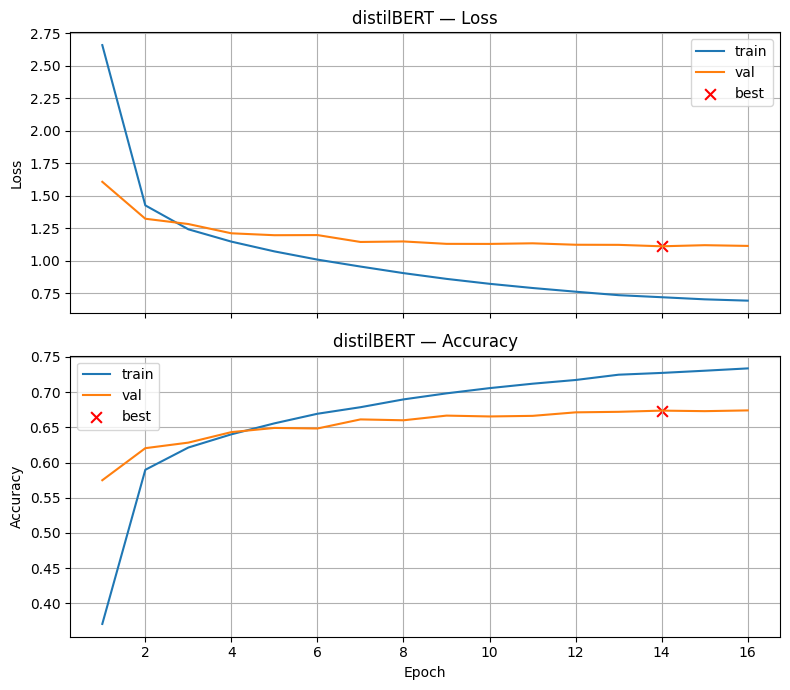

Best epoch: 14
Val loss:   1.1113
Val acc:    0.6737


In [22]:
best_ep, val_acc = plot_learning_curves(history, "distilBERT")

In [23]:
y_pred_distilbert = evaluate_model(
    model=p4_model,
    name="DistilBERT",
    X_te=test_ds,
    y_te=y_test_final,
    hist=history,
    train_time=train_time,
    batch_size=BATCH
)

Results saved (1 models)


### Confusion Matrix

In [24]:


cm = confusion_matrix(y_test_final, y_pred_distilbert)

confused = []
for i in range(num_classes):
    for j in range(num_classes):
        if i != j and cm[i, j] > 0:
            confused.append((cm[i, j], class_names[i], class_names[j]))
confused.sort(reverse=True)

print("Top 10 confused pairs (true -> predicted, count):")
# for count, true, pred in confused[:10]:
#     print(f"  {true:25s} -> {pred:25s}  ({count})”)

save_confused_pairs(confused,model_name="distilBERT", top_n=10)

Top 10 confused pairs (true -> predicted, count):


,Model,Count,True Label,Predicted Label
0,distilBERT,160,HOME & LIVING,WELLNESS
1,distilBERT,156,POLITICS,MEDIA
2,distilBERT,133,POLITICS,WORLD NEWS
3,distilBERT,128,ENTERTAINMENT,COMEDY
4,distilBERT,111,POLITICS,BUSINESS
5,distilBERT,104,POLITICS,BLACK VOICES
6,distilBERT,93,POLITICS,ENVIRONMENT
7,distilBERT,93,POLITICS,CRIME
8,distilBERT,83,WELLNESS,HOME & LIVING
9,distilBERT,79,POLITICS,WOMEN


### Per-Class F1 Analysis

Macro F1 hides per-class variation. The bar chart below ranks all 31 categories by test F1 to highlight the strongest and weakest.

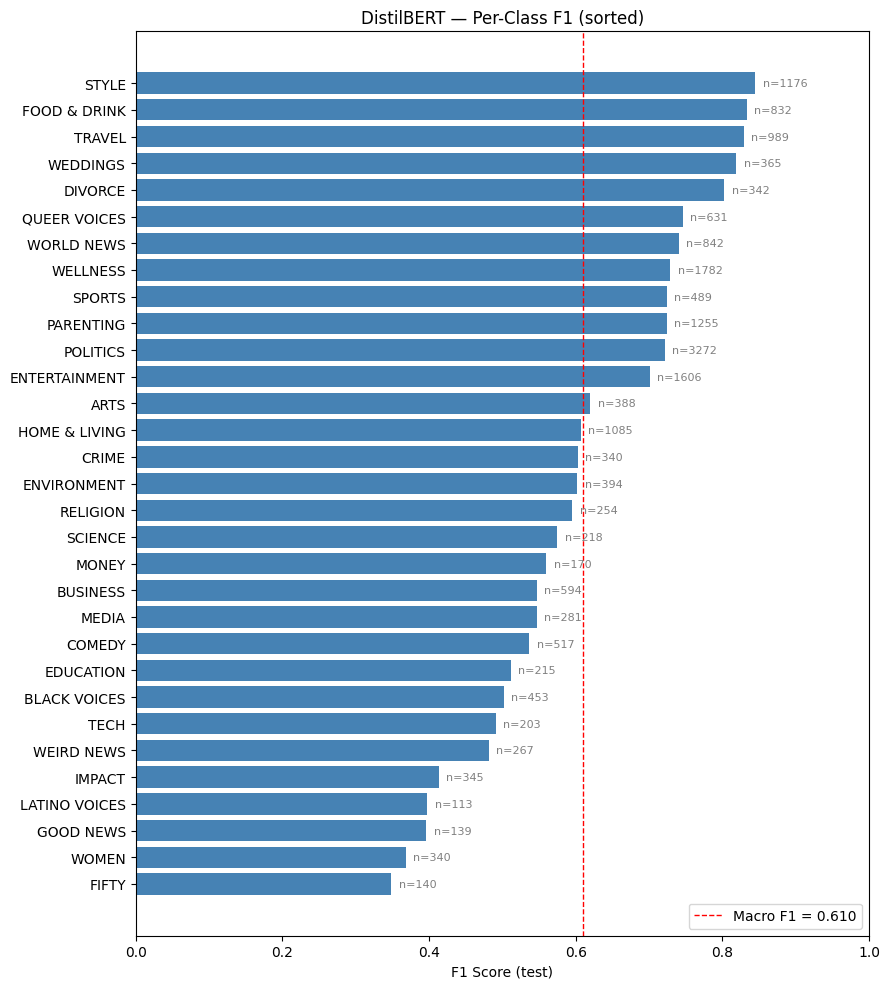


Weakest 5 classes:
        class       f1  support
        FIFTY 0.348668      140
        WOMEN 0.368113      340
    GOOD NEWS 0.396450      139
LATINO VOICES 0.397626      113
       IMPACT 0.413043      345

Strongest 5 classes:
       class       f1  support
       STYLE 0.845156     1176
FOOD & DRINK 0.833040      832
      TRAVEL 0.829469      989
    WEDDINGS 0.819121      365
     DIVORCE 0.802837      342


In [25]:
from sklearn.metrics import f1_score

per_class_f1 = f1_score(y_test_final, test_pred, average=None)
support = np.bincount(y_test_final, minlength=num_classes)

f1_df = pd.DataFrame({
    "class": [id2label[i] for i in range(num_classes)],
    "f1": per_class_f1,
    "support": support,
}).sort_values("f1", ascending=True)

fig, ax = plt.subplots(figsize=(9, 10))
bars = ax.barh(f1_df["class"], f1_df["f1"], color="steelblue")
ax.axvline(f1_df["f1"].mean(), color="red", linestyle="--", linewidth=1,
           label=f"Macro F1 = {f1_df['f1'].mean():.3f}")
ax.set_xlabel("F1 Score (test)")
ax.set_title("DistilBERT — Per-Class F1 (sorted)")
ax.set_xlim(0, 1)
ax.legend(loc="lower right")
for bar, n in zip(bars, f1_df["support"]):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f"n={n}", va="center", fontsize=8, color="gray")
plt.tight_layout()
plt.savefig("results/per_class_f1.png", dpi=120, bbox_inches="tight")
plt.show()

print("\nWeakest 5 classes:")
print(f1_df.head(5).to_string(index=False))
print("\nStrongest 5 classes:")
print(f1_df.tail(5).iloc[::-1].to_string(index=False))

### Normalized Confusion Matrix (row %)

Raw counts are dominated by POLITICS (largest class). Normalizing each row by its true-class total reveals where each class *actually* gets routed.

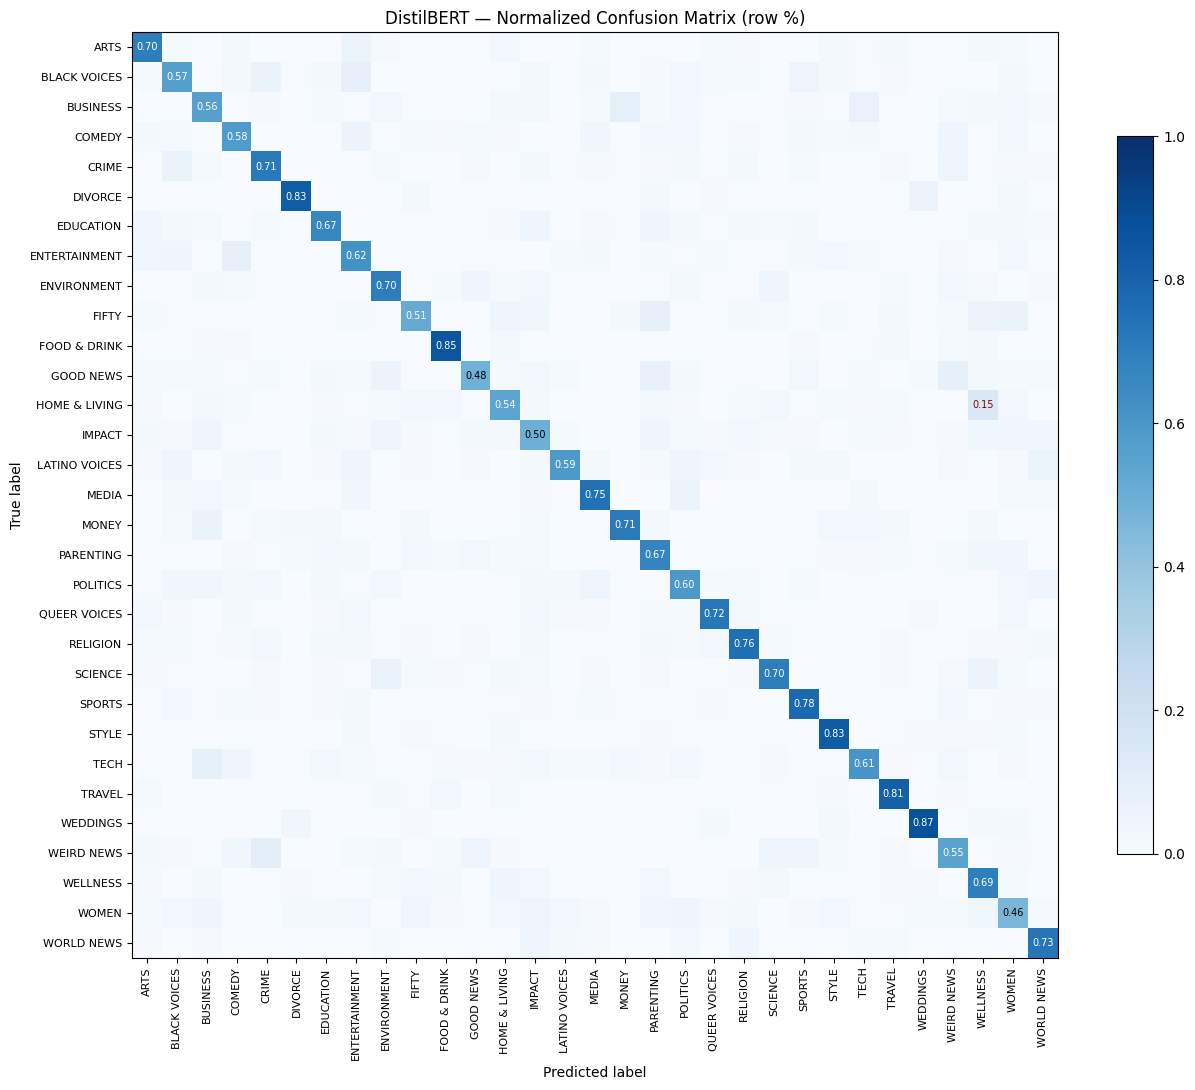

In [26]:
import matplotlib.pyplot as plt

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(13, 11))
im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(num_classes))
ax.set_yticks(range(num_classes))
ax.set_xticklabels([id2label[i] for i in range(num_classes)], rotation=90, fontsize=8)
ax.set_yticklabels([id2label[i] for i in range(num_classes)], fontsize=8)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("DistilBERT — Normalized Confusion Matrix (row %)")

# Annotate diagonal + largest off-diagonal per row only (keeps plot readable)
for i in range(num_classes):
    ax.text(i, i, f"{cm_norm[i,i]:.2f}", ha="center", va="center",
            color="white" if cm_norm[i,i] > 0.5 else "black", fontsize=7)
    off_diag = cm_norm[i].copy(); off_diag[i] = 0
    j = off_diag.argmax()
    if off_diag[j] >= 0.10:
        ax.text(j, i, f"{off_diag[j]:.2f}", ha="center", va="center",
                color="white" if off_diag[j] > 0.5 else "darkred", fontsize=7)

fig.colorbar(im, ax=ax, fraction=0.03)
plt.tight_layout()
plt.savefig("results/confusion_matrix_normalized.png", dpi=120, bbox_inches="tight")
plt.show()

### Top-10 Misclassified Pairs

Visualization of the `confused` list computed above — the dominant failure modes of the model.

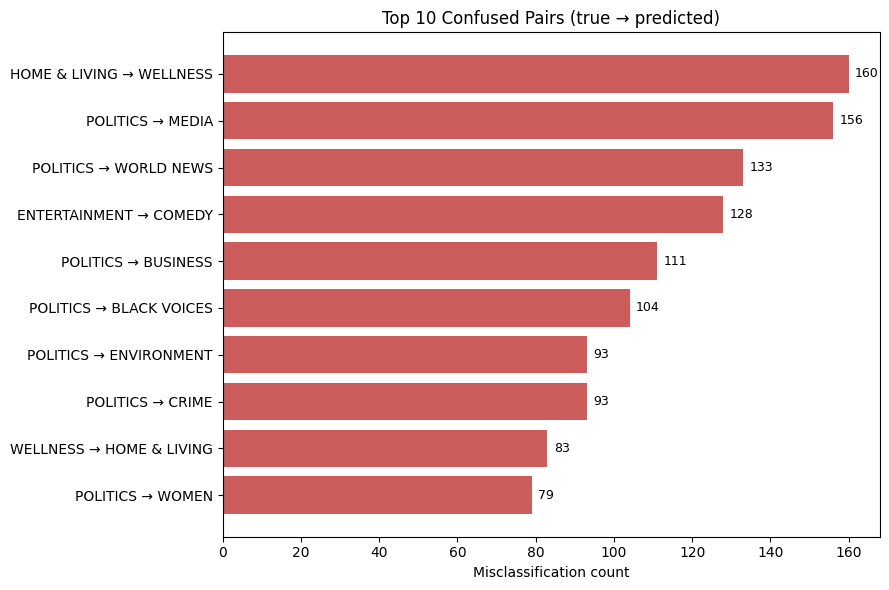

In [27]:
top_confused = confused[:10]
labels = [f"{t} → {p}" for (_, t, p) in top_confused]
counts = [c for (c, _, _) in top_confused]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(labels[::-1], counts[::-1], color="indianred")
ax.set_xlabel("Misclassification count")
ax.set_title("Top 10 Confused Pairs (true → predicted)")
for i, c in enumerate(counts[::-1]):
    ax.text(c + max(counts)*0.01, i, str(c), va="center", fontsize=9)
plt.tight_layout()
plt.savefig("results/top_confused_pairs.png", dpi=120, bbox_inches="tight")
plt.show()

### Error Analysis — Sampled Misclassified Headlines

Qualitative look at *why* the model errs. Samples are drawn from the most-confused pairs above.

In [28]:
rng = np.random.default_rng(SEED)
misclassified_idx = np.where(y_test_final != test_pred)[0]
print(f"Total misclassified: {len(misclassified_idx):,} / {len(y_test_final):,} "
      f"({len(misclassified_idx)/len(y_test_final):.1%})\n")

# Sample 15 from the top confused pairs for focused error analysis
top_pairs = [(t, p) for (_, t, p) in confused[:5]]
print("Sampled misclassifications from top-5 confused pairs:\n")
print(f"{'#':<3} {'TRUE':<18} {'PRED':<18} HEADLINE")
print("-" * 120)

shown = 0
for true_c, pred_c in top_pairs:
    t_id, p_id = label2id[true_c], label2id[pred_c]
    mask = (y_test_final == t_id) & (test_pred == p_id)
    idxs = np.where(mask)[0]
    if len(idxs) == 0:
        continue
    picked = rng.choice(idxs, size=min(3, len(idxs)), replace=False)
    for i in picked:
        headline = X_test[i][:90].replace("[SEP]", "|")
        print(f"{shown+1:<3} {true_c:<18} {pred_c:<18} {headline}")
        shown += 1
    print()

Total misclassified: 6,567 / 20,037 (32.8%)

Sampled misclassifications from top-5 confused pairs:

#   TRUE               PRED               HEADLINE
------------------------------------------------------------------------------------------------------------------------
1   HOME & LIVING      WELLNESS           The Untouched Generation | Everything in life has two sides, it is better to look at t
2   HOME & LIVING      WELLNESS           I tried Bikram (aka Yoga in Hell or 'Hot Yoga') | I tried hot yoga and I tried Bikram.
3   HOME & LIVING      WELLNESS           Is Genetic Testing for Breast Cancer Right for You? | While it's natural to wonder if 

4   POLITICS           MEDIA              Joe Scarborough To Donald Trump: You're Acting Like A Racist Bigot | "Don't use Hillar
5   POLITICS           MEDIA              New York Times Editorial Board Endorses John Kasich For GOP Nomination | The battle to
6   POLITICS           MEDIA              MSNBC's 'Morning Joe' Viciously Blasts '

### Support vs F1 Scatter

Relationship between class size (test support) and per-class F1. A positive trend would indicate imbalance-driven performance gaps.

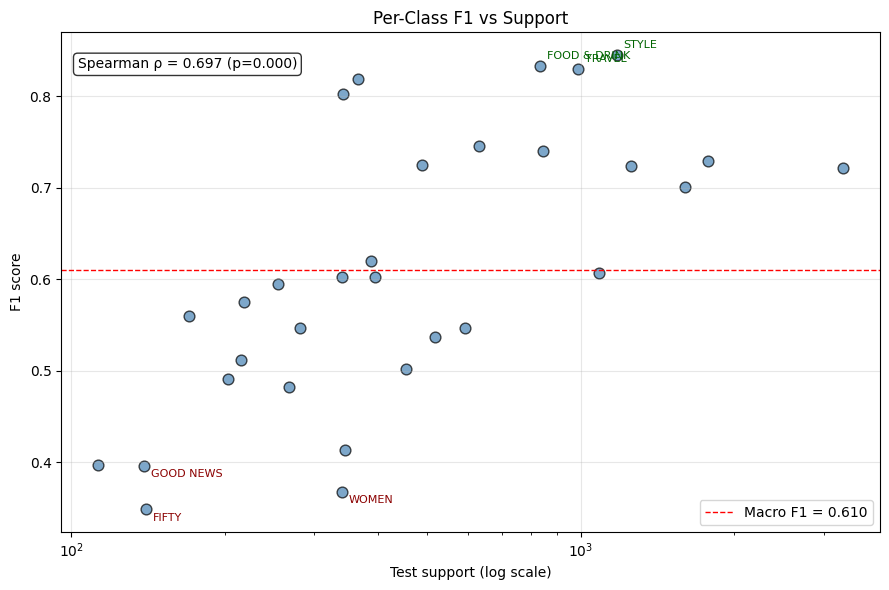


Spearman correlation between support and F1: ρ = 0.697 (p = 0.000)


In [29]:
from scipy.stats import spearmanr

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(f1_df["support"], f1_df["f1"], s=60, alpha=0.7, color="steelblue", edgecolor="black")
ax.set_xscale("log")
ax.set_xlabel("Test support (log scale)")
ax.set_ylabel("F1 score")
ax.set_title("Per-Class F1 vs Support")
ax.axhline(f1_df["f1"].mean(), color="red", linestyle="--", linewidth=1,
           label=f"Macro F1 = {f1_df['f1'].mean():.3f}")

# Annotate 3 weakest and 3 strongest classes
for _, r in f1_df.head(3).iterrows():
    ax.annotate(r["class"], (r["support"], r["f1"]), fontsize=8,
                xytext=(5, -8), textcoords="offset points", color="darkred")
for _, r in f1_df.tail(3).iterrows():
    ax.annotate(r["class"], (r["support"], r["f1"]), fontsize=8,
                xytext=(5, 5), textcoords="offset points", color="darkgreen")

rho, pval = spearmanr(f1_df["support"], f1_df["f1"])
ax.text(0.02, 0.95, f"Spearman ρ = {rho:.3f} (p={pval:.3f})",
        transform=ax.transAxes, fontsize=10, verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("results/support_vs_f1.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"\nSpearman correlation between support and F1: ρ = {rho:.3f} (p = {pval:.3f})")

### Model Comparison: DistilBERT vs Milestone 2 Baselines

Side-by-side comparison of all models trained across Milestone 2 and the final project. DistilBERT's performance gain justifies its higher compute cost.

Model comparison (DistilBERT vs Milestone 2 baselines):

                        Model  Test Acc  Macro F1  Val Acc  Best Epoch     Params Train Time (s)
          Baseline (Emb+Pool)    0.5638    0.4987   0.5613          11  1,286,175            37s
                         LSTM    0.5342    0.4616   0.5405          11  1,319,199            37s
                       BiLSTM    0.5602    0.4867   0.5610           6  1,356,319            37s
            Enhanced Baseline    0.5536    0.4889   0.5427           3  1,299,359            37s
DistilBERT (final, full data)    0.6723    0.6104   0.6737          14 66,977,311        158m 2s


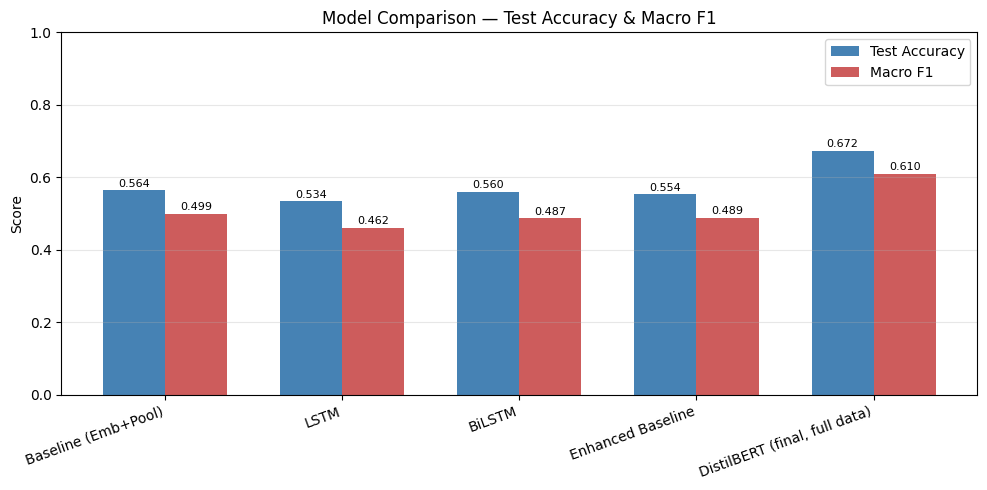

In [30]:
# Baseline results from Milestone 2 (reproduced from results/ms2_results.json)
m2_baselines = [
    {"Model": "Baseline (Emb+Pool)", "Test Acc": 0.5638, "Macro F1": 0.4987,
     "Val Acc": 0.5613, "Best Epoch": 11, "Params": 1_286_175, "Train Time (s)": 37},
    {"Model": "LSTM",                 "Test Acc": 0.5342, "Macro F1": 0.4616,
     "Val Acc": 0.5405, "Best Epoch": 11, "Params": 1_319_199, "Train Time (s)": 37},
    {"Model": "BiLSTM",               "Test Acc": 0.5602, "Macro F1": 0.4867,
     "Val Acc": 0.5610, "Best Epoch":  6, "Params": 1_356_319, "Train Time (s)": 37},
    {"Model": "Enhanced Baseline",    "Test Acc": 0.5536, "Macro F1": 0.4889,
     "Val Acc": 0.5427, "Best Epoch":  3, "Params": 1_299_359, "Train Time (s)": 37},
]

# DistilBERT from the current run (pulled from results dict populated by evaluate_model)
db = results.get("DistilBERT", {})
m2_baselines.append({
    "Model": "DistilBERT (final, full data)",
    "Test Acc": round(db.get("test_acc", float("nan")), 4),
    "Macro F1": round(db.get("test_f1", float("nan")), 4),
    "Val Acc": round(db.get("val_acc", float("nan")), 4),
    "Best Epoch": db.get("best_epoch", "—"),
    "Params": db.get("params", 66_977_311),
    "Train Time (s)": round(db.get("train_time", 0)),
})

comparison_df = pd.DataFrame(m2_baselines)
comparison_df["Params"] = comparison_df["Params"].apply(lambda x: f"{x:,}")
comparison_df["Train Time (s)"] = comparison_df["Train Time (s)"].apply(
    lambda s: f"{int(s)//60}m {int(s)%60}s" if s >= 60 else f"{s}s"
)

# Save CSV for the report
comparison_df.to_csv("results/model_comparison.csv", index=False)

print("Model comparison (DistilBERT vs Milestone 2 baselines):\n")
print(comparison_df.to_string(index=False))

# Bar chart: Test Acc & Macro F1 side by side
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(comparison_df))
w = 0.35
ax.bar(x - w/2, comparison_df["Test Acc"], w, label="Test Accuracy", color="steelblue")
ax.bar(x + w/2, comparison_df["Macro F1"], w, label="Macro F1", color="indianred")
ax.set_xticks(x)
ax.set_xticklabels(comparison_df["Model"], rotation=20, ha="right")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.set_title("Model Comparison — Test Accuracy & Macro F1")
ax.legend()
ax.grid(axis="y", alpha=0.3)
for i, (acc, f1) in enumerate(zip(comparison_df["Test Acc"], comparison_df["Macro F1"])):
    ax.text(i - w/2, acc + 0.01, f"{acc:.3f}", ha="center", fontsize=8)
    ax.text(i + w/2, f1 + 0.01, f"{f1:.3f}", ha="center", fontsize=8)
plt.tight_layout()
plt.savefig("results/model_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

### Final Results

> Numbers below will be updated after the full-dataset run completes.
> Previous 50%-subset baseline (for reference): Test Acc 0.708, Macro F1 0.621.

Key observations to update post-run:
- Final Test Accuracy / Macro F1 on the full training set
- Per-class F1 shifts (esp. minority classes: FIFTY, GOOD NEWS, WOMEN)
- Whether the dominant confusion pairs change
- Total training time